## 売れやすい商品の特定

## ロジスティック回帰 / 決定木を持ちいて行う

In [101]:
import pandas as pd

In [102]:
# 2つのCSVファイルを読み込み
sake_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-sake/buy_check_dummy_data.csv', encoding='utf-8')
whisky_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-whisky/buy_check_dummy_data_whisky.csv', encoding='utf-8')
data = pd.concat([sake_data, whisky_data], ignore_index=True)
data.head()

,購入ID,商品ID,商品名,単価,数量,総価格,顧客ID,購入日時
0,1,1,獺祭２割3分,5900,2,11800,1087,2025-04-01 14:58:00
1,2,1,獺祭２割3分,5900,1,5900,1007,2025-04-01 12:43:00
2,3,1,獺祭２割3分,5900,3,17700,1062,2025-04-01 14:52:00
3,4,1,獺祭２割3分,5900,2,11800,1033,2025-04-01 18:25:00
4,5,1,獺祭２割3分,5900,3,17700,1084,2025-04-01 14:18:00


In [103]:
# 売上本数が記録された列の名前を仮に 'bottle_sold' とします（実際の列名に置き換えてください）
# 1本だけ → '不調'、2本以上 → '好調'

# 数量が1なら「不調」、2本以上なら「好調」とする新しいカラムを作成
data['売れ行き'] = data['数量'].apply(lambda x: '不調' if x == 1 else '好調')

data.head()

,購入ID,商品ID,商品名,単価,数量,総価格,顧客ID,購入日時,売れ行き
0,1,1,獺祭２割3分,5900,2,11800,1087,2025-04-01 14:58:00,好調
1,2,1,獺祭２割3分,5900,1,5900,1007,2025-04-01 12:43:00,不調
2,3,1,獺祭２割3分,5900,3,17700,1062,2025-04-01 14:52:00,好調
3,4,1,獺祭２割3分,5900,2,11800,1033,2025-04-01 18:25:00,好調
4,5,1,獺祭２割3分,5900,3,17700,1084,2025-04-01 14:18:00,好調


In [104]:
# '数量'に基づいて「好調」「不調」を判定し、数値ラベルとして新しいカラムに格納
data['売れ行きラベル'] = data['数量'].apply(lambda x: 0 if x == 1 else 1)

# 結果を確認
data.head()


,購入ID,商品ID,商品名,単価,数量,総価格,顧客ID,購入日時,売れ行き,売れ行きラベル
0,1,1,獺祭２割3分,5900,2,11800,1087,2025-04-01 14:58:00,好調,1
1,2,1,獺祭２割3分,5900,1,5900,1007,2025-04-01 12:43:00,不調,0
2,3,1,獺祭２割3分,5900,3,17700,1062,2025-04-01 14:52:00,好調,1
3,4,1,獺祭２割3分,5900,2,11800,1033,2025-04-01 18:25:00,好調,1
4,5,1,獺祭２割3分,5900,3,17700,1084,2025-04-01 14:18:00,好調,1


In [105]:
# DataFrame化
columns = ['購入ID', '商品ID', '商品名', '単価', '数量', '総価格', '顧客ID', '購入日時']
df = pd.DataFrame(data, columns=columns)

# 商品名ごとに '数量' と '総価格' を合計
summary = df.groupby('商品名')[['数量']].sum().reset_index()

# 表示
print(summary)

                            商品名    数量
0                         LINK8    80
1                   あかし シングルモルト   602
2                 あかし7年 シングルモルト    69
3                くら ブレンデットウイスキー   393
4   くら ラムスカスクフィニッシュ ブレンデットウイスキー   428
5         サントリーローヤル ブレンデットウイスキー   474
6                      九平次human   660
7                         九平次別誂   406
8                        九平次彼の岸   299
9                    余市　シングルモルト   533
10                   倉吉 シングルモルト   253
11            倉吉12年 ブレンデットウイスキー   240
12            倉吉18年 ブレンデットウイスキー   185
13            倉吉25年 ブレンデットウイスキー   117
14            倉吉29年 ブレンデットウイスキー   105
15            倉吉31年 ブレンデットウイスキー    37
16                          八海山   477
17                    八海山　浩和蔵仕込   171
18                      千代菊　大吟醸   401
19                      千代菊日本人形   393
20                       大関十段仕込   294
21                          宮の雪   147
22                  宮城峡　シングルモルト   429
23              富士山 ブレンデットウイスキー   205
24             小正嘉之介MBR シングルモルト   355
25          

In [106]:
# 購入日時を datetime 型に変換し、日付部分だけを取り出す
data['購入日'] = pd.to_datetime(data['購入日時']).dt.date

# 商品名と日付ごとの購入件数をカウント（行数＝件数）
daily_product_counts = data.groupby(['購入日', '商品名']).size().reset_index(name='購入件数')

# 結果を表示
print(daily_product_counts)

             購入日                          商品名  購入件数
0     2025-04-01                        LINK8     1
1     2025-04-01                  あかし シングルモルト    13
2     2025-04-01                あかし7年 シングルモルト     1
3     2025-04-01               くら ブレンデットウイスキー     6
4     2025-04-01  くら ラムスカスクフィニッシュ ブレンデットウイスキー     5
...          ...                          ...   ...
1392  2025-04-30                         神巖富士     6
1393  2025-04-30                          菊正宗     1
1394  2025-04-30                           酔心     5
1395  2025-04-30                         雪の茅宿     2
1396  2025-04-30                  鳳凰酔心　山田綿50%     5

[1397 rows x 3 columns]


/var/folders/nq/pf4848v92qq76wvlqb4x38j40000gn/T/ipykernel_70802/2887064806.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ranked_data = grouped.groupby('購入日', group_keys=False).apply(assign_sales_rank)


テスト精度: 0.6


/Users/yugo_suzuki/Lecture/MD/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


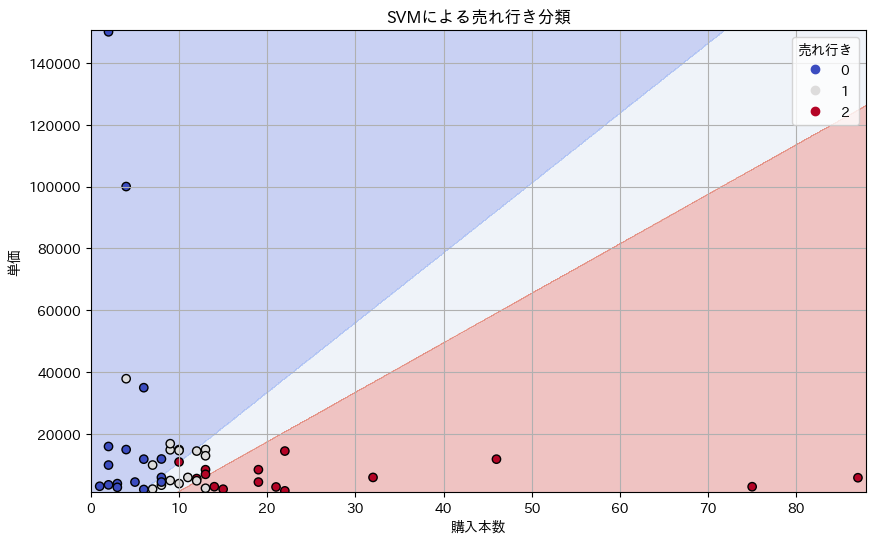


========== 各ランクの商品名 ==========

🔴 売れてる（赤）:
 - 獺祭２割3分
 - 獺祭３割9分
 - 獺祭早田
 - 桜尾 シングルモルト
 - あかし シングルモルト
 - 余市　シングルモルト
 - 戸河内 ブレンデットウイスキー
 - くら ラムスカスクフィニッシュ ブレンデットウイスキー
 - 九平次human
 - 千代菊　大吟醸
 - 千代菊日本人形
 - 八海山
 - 小正嘉之介MBR シングルモルト
 - サントリーローヤル ブレンデットウイスキー
 - 碧AO ブレンデットウイスキー

🔴 普通（オレンジ）:
 - 桜尾四季 シングルモルト
 - 小正嘉之介MDS シングルモルト
 - 九平次別誂
 - 神巖富士
 - 酔心
 - くら ブレンデットウイスキー
 - 富士山 ブレンデットウイスキー
 - 宮城峡　シングルモルト
 - 倉吉 シングルモルト
 - 倉吉12年 ブレンデットウイスキー
 - 大関十段仕込
 - 九平次彼の岸
 - 岡山　シングルモルト
 - 獺祭未来へ農家と共に
 - 八海山　浩和蔵仕込
 - 獺祭磨きその先に

🔴 売れてない（青）:
 - 桜尾 SHERRY-CASK シングルモルト
 - 鳳凰酔心　山田綿50%
 - 戸河内四季 ブレンデットウイスキー
 - 宮の雪
 - 倉吉25年 ブレンデットウイスキー
 - 倉吉18年 ブレンデットウイスキー
 - 月桂冠大吟醸山田綿
 - 小正嘉之介W-Ds MBR シングルモルト
 - 雪の茅宿
 - LINK8
 - 月桂冠龍馬伝
 - 月桂冠純米大吟醸
 - 倉吉29年 ブレンデットウイスキー
 - 菊正宗
 - あかし7年 シングルモルト
 - 鳳凰酔心　山田綿30%


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# ★ここで4月1日にフィルター
data = data[data['購入日'] == pd.to_datetime("2025-04-05").date()]

# 各日・各商品ごとの購入件数（行数）と購入本数（数量合計）を集計
grouped = data.groupby(['購入日', '商品名']).agg(
    購入件数=('購入ID', 'count'),
    購入本数=('数量', 'sum'),
    単価=('単価', 'first')
).reset_index()

# 各日ごとに3分位に分けてランク付け（売れてる: 2、普通: 1、売れてない: 0）
def assign_sales_rank(df):
    df_sorted = df.sort_values('購入件数', ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    top = n // 3
    mid = 2 * n // 3
    df_sorted['売れ行き'] = 0  # デフォルトは売れていない
    df_sorted.loc[:top-1, '売れ行き'] = 2
    df_sorted.loc[top:mid-1, '売れ行き'] = 1
    return df_sorted

# 各購入日に対してランクを計算
ranked_data = grouped.groupby('購入日', group_keys=False).apply(assign_sales_rank)

# 特徴量とラベルの準備
X = ranked_data[['購入本数', '単価']]
y = ranked_data['売れ行き']

# データ分割（標準化なし）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVMモデル作成（3クラス分類）
model = SVC(kernel='linear',C=3.5, random_state=62, decision_function_shape='ovr',gamma='scale')
model.fit(X_train, y_train)

# 精度表示
print("テスト精度:", model.score(X_test, y_test))

# -----------------------
# 可視化
# -----------------------

# グリッド作成
h = 0.1
x_min, x_max = X['購入本数'].min() - 1, X['購入本数'].max() + 1
y_min, y_max = X['単価'].min() - 500, X['単価'].max() + 500
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, 100))

# グリッドに対して予測
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# プロット
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X['購入本数'], X['単価'], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('購入本数')
plt.ylabel('単価')
plt.title('SVMによる売れ行き分類')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="売れ行き")
plt.show()

print("\n========== 各ランクの商品名 ==========")
for rank_value, rank_label in zip([2, 1, 0], ['売れてる（赤）', '普通（オレンジ）', '売れてない（青）']):
    items = ranked_data[ranked_data['売れ行き'] == rank_value]['商品名'].tolist()
    print(f"\n🔴 {rank_label}:")
    for name in items:
        print(f" - {name}")

/var/folders/nq/pf4848v92qq76wvlqb4x38j40000gn/T/ipykernel_70802/2594423011.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ranked_data = grouped.groupby('購入日', group_keys=False).apply(assign_sales_rank)


========== テスト結果 ==========
✔️ テスト精度: 0.900

✔️ 分類レポート:
              precision    recall  f1-score   support

       売れてない       1.00      1.00      1.00         4
          普通       0.75      1.00      0.86         3
        売れてる       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.89      0.89        10
weighted avg       0.93      0.90      0.90        10

✔️ 混同行列:
[[4 0 0]
 [0 3 0]
 [0 1 2]]


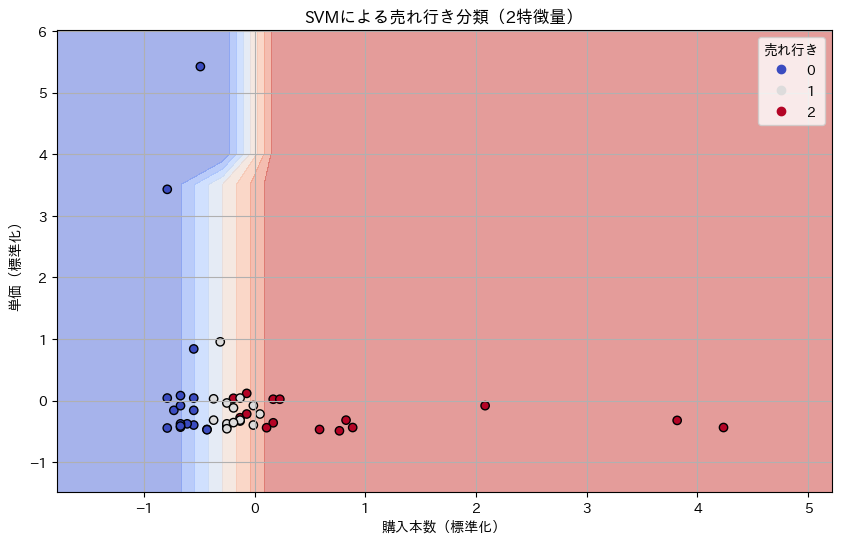


========== 各ランクの商品名 ==========

🔴 売れてる（赤）:
 - 獺祭３割9分
 - 獺祭２割3分
 - 獺祭早田
 - 桜尾 シングルモルト
 - 戸河内 ブレンデットウイスキー
 - あかし シングルモルト
 - 余市　シングルモルト
 - 八海山
 - 宮城峡　シングルモルト
 - 九平次別誂
 - 獺祭未来へ農家と共に
 - 九平次human
 - サントリーローヤル ブレンデットウイスキー
 - 千代菊日本人形
 - 九平次彼の岸

🔴 普通（オレンジ）:
 - 酔心
 - 碧AO ブレンデットウイスキー
 - くら ブレンデットウイスキー
 - 桜尾四季 シングルモルト
 - 小正嘉之介MDS シングルモルト
 - くら ラムスカスクフィニッシュ ブレンデットウイスキー
 - 小正嘉之介MBR シングルモルト
 - 千代菊　大吟醸
 - 桜尾 SHERRY-CASK シングルモルト
 - 神巖富士
 - 倉吉 シングルモルト
 - 富士山 ブレンデットウイスキー
 - 獺祭磨きその先に
 - 岡山　シングルモルト
 - 戸河内四季 ブレンデットウイスキー
 - 大関十段仕込

🔴 売れてない（青）:
 - 鳳凰酔心　山田綿50%
 - 八海山　浩和蔵仕込
 - 倉吉12年 ブレンデットウイスキー
 - 月桂冠龍馬伝
 - 宮の雪
 - 倉吉29年 ブレンデットウイスキー
 - 倉吉18年 ブレンデットウイスキー
 - 月桂冠純米大吟醸
 - 月桂冠大吟醸山田綿
 - 小正嘉之介W-Ds MBR シングルモルト
 - 倉吉25年 ブレンデットウイスキー
 - 菊正宗
 - あかし7年 シングルモルト
 - 雪の茅宿
 - 鳳凰酔心　山田綿30%
 - LINK8


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ① データ読み込み済み前提。4月1日にフィルター
data = data[data['購入日'] == pd.to_datetime("2025-04-01").date()]

# ② 商品ごとの集計
grouped = data.groupby(['購入日', '商品名']).agg(
    購入件数=('購入ID', 'count'),
    購入本数=('数量', 'sum'),
    単価=('単価', 'first')
).reset_index()

# ③ 購入件数ベースのランク付け（売れてる：2、中間：1、売れてない：0）
def assign_sales_rank(df):
    df_sorted = df.sort_values('購入件数', ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    top = n // 3
    mid = 2 * n // 3
    df_sorted['売れ行き'] = 0
    df_sorted.loc[:top-1, '売れ行き'] = 2
    df_sorted.loc[top:mid-1, '売れ行き'] = 1
    return df_sorted

ranked_data = grouped.groupby('購入日', group_keys=False).apply(assign_sales_rank)

# ④ 特徴量・ラベル設定
X = ranked_data[['購入本数', '単価', '購入件数']]
y = ranked_data['売れ行き']

# ⑤ 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ⑥ 訓練・テスト分割
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ⑦ モデル作成と学習
model = SVC(kernel='linear', C=3.0, decision_function_shape='ovr', random_state=42)
model.fit(X_train, y_train)

# ⑧ 予測と評価
y_pred = model.predict(X_test)

# 評価出力
print("========== テスト結果 ==========")
print(f"✔️ テスト精度: {accuracy_score(y_test, y_pred):.3f}")
print("\n✔️ 分類レポート:")
print(classification_report(y_test, y_pred, target_names=["売れてない", "普通", "売れてる"]))

print("✔️ 混同行列:")
print(confusion_matrix(y_test, y_pred))

# ⑨ 可視化（2次元用の購入本数＆単価のみで別途表示）
X_2d = X[['購入本数', '単価']]
X_2d_scaled = scaler.fit_transform(X_2d)

model_2d = SVC(kernel='linear', C=3.5, decision_function_shape='ovr', random_state=42, gamma='scale')
model_2d.fit(X_2d_scaled, y)

# グリッド作成
h = 0.5
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ⑩ 図示
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('購入本数（標準化）')
plt.ylabel('単価（標準化）')
plt.title('SVMによる売れ行き分類（2特徴量）')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="売れ行き")
plt.show()

print("\n========== 各ランクの商品名 ==========")
for rank_value, rank_label in zip([2, 1, 0], ['売れてる（赤）', '普通（オレンジ）', '売れてない（青）']):
    items = ranked_data[ranked_data['売れ行き'] == rank_value]['商品名'].tolist()
    print(f"\n🔴 {rank_label}:")
    for name in items:
        print(f" - {name}")
